In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import ElasticNet
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

## business understanding

- This problem states to predict the price of the house based on some information such as median income, house age, avg rooms, avg bedrooms, population, avg occupy, lattitude and longtitude.
- The target variable is `MedhouseVal`.
- This is a house price prediction problem. As price is a numeric and continuous value, so this is a regression problem.

## load dataset

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


- Business Understanding
        ↓
- Load Dataset
        ↓
- EDA
        ↓
- Cleaning
        ↓
- Feature Engineering
        ↓
- Train/Test Split
        ↓
- Baseline Model
        ↓
- Cross Validation
        ↓
- Regularization
        ↓
- Hyperparameter Tuning
        ↓
- Pipeline
        ↓
- Feature Selection
        ↓
- Final Evaluation
        ↓
- Business Conclusion

## EDA

In [3]:
df.shape

(20640, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
df.skew()

,0
MedInc,1.646657
HouseAge,0.060331
AveRooms,20.697869
AveBedrms,31.316956
Population,4.935858
AveOccup,97.639561
Latitude,0.465953
Longitude,-0.297801
MedHouseVal,0.977763


In [11]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


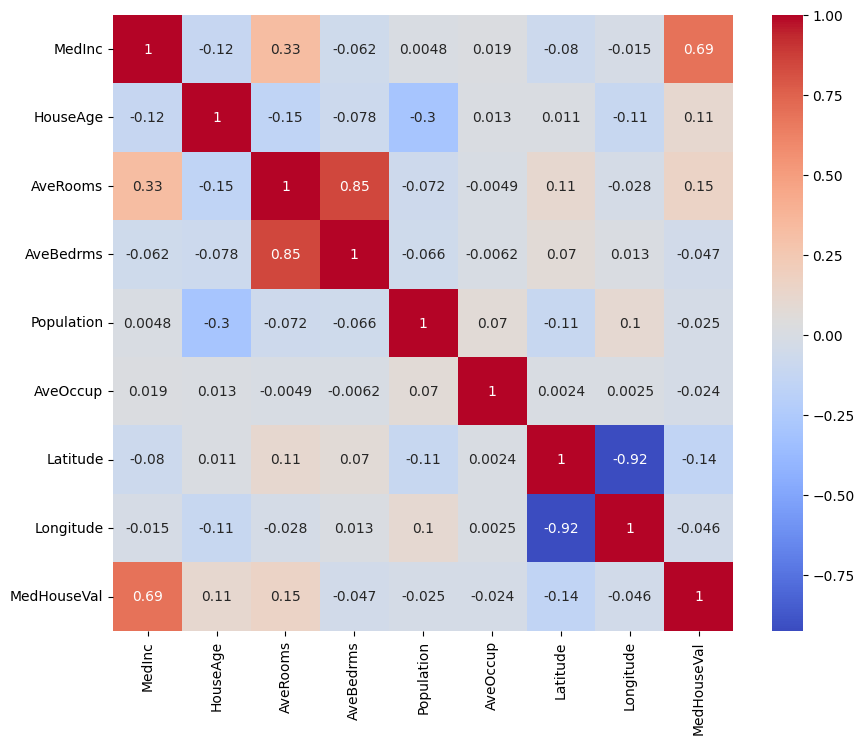

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

- In the heatmap we can see the correlations between the features and target.
- SOme features have positive correlation with the target variable and some have negative.
- Among all, MedInc has the highest correlation with the House Price and it is positive correlation.
- AvgOccup has the lowest correlation and it's negatively correlated.


### Visualization

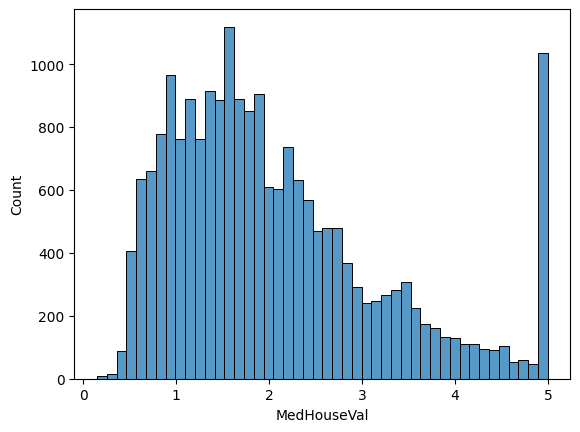

In [14]:
sns.histplot(df['MedHouseVal'])
plt.show()

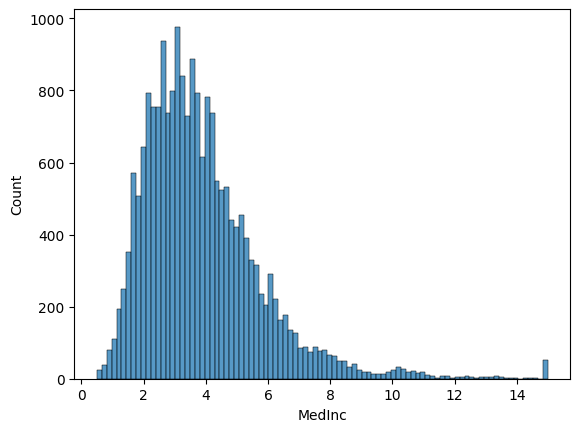

In [15]:
sns.histplot(df['MedInc'])
plt.show()

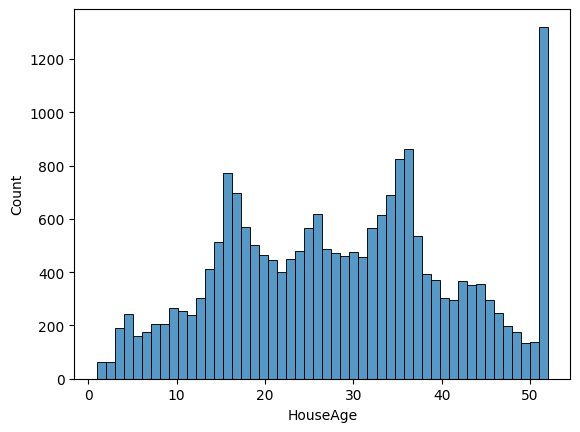

In [16]:
sns.histplot(df['HouseAge'], bins = 50)
plt.show()

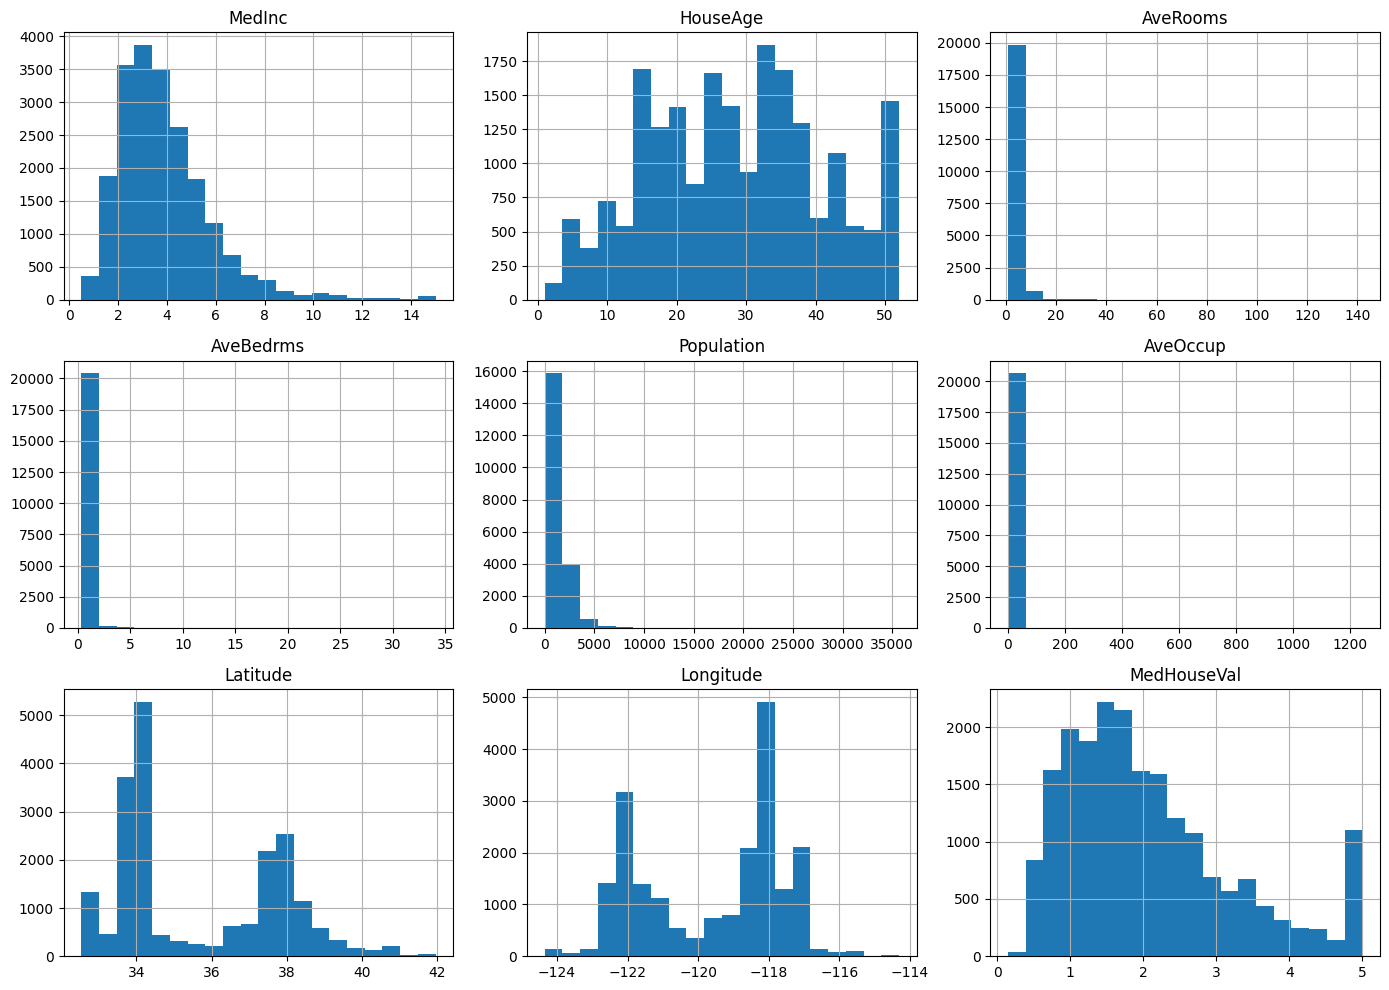

In [17]:
df.hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()

From the histogram plot it can be seen that, Medinc data is right skewed, most people tend to have income between 2 to 5. Houseage is comparatively bell curved with some spikes.  The target column House Price is also right skewed with right most values are capped to 5.

<Figure size 1000x800 with 0 Axes>

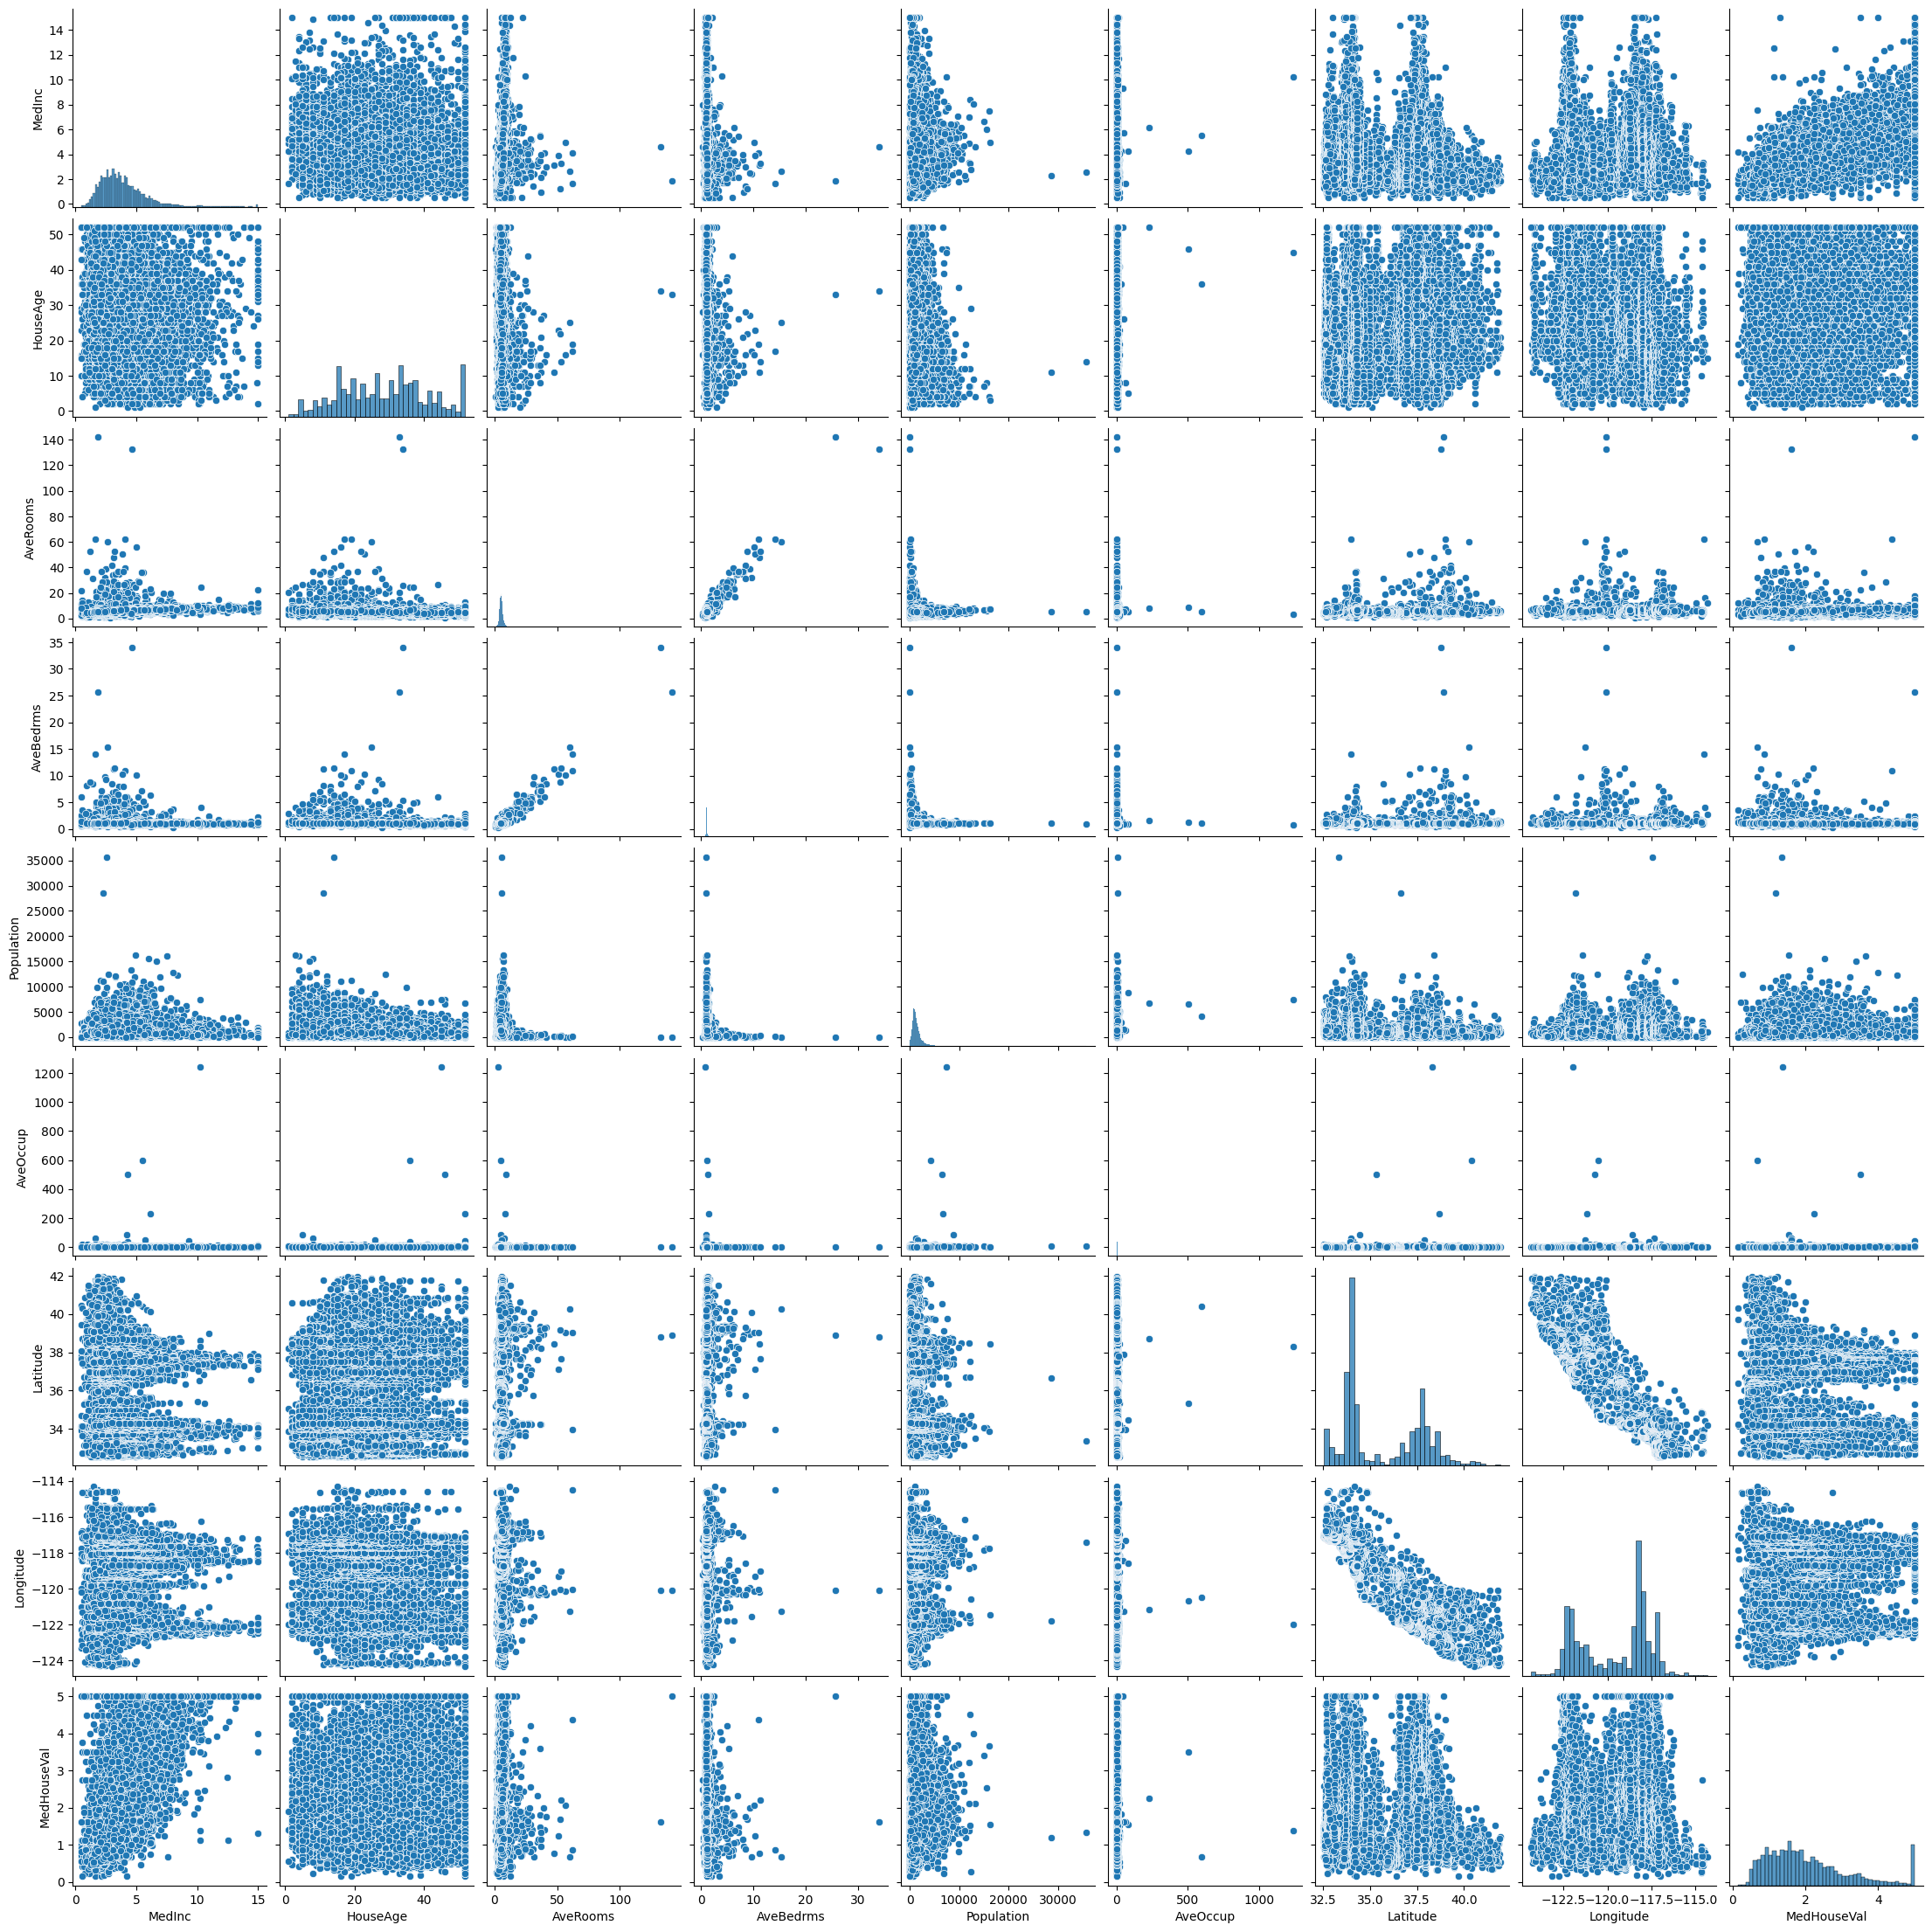

In [18]:
plt.figure(figsize=(10, 8))
sns.pairplot(df)
plt.show()


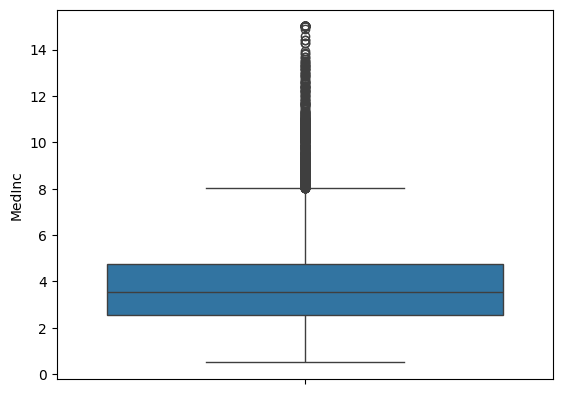

In [19]:
sns.boxplot(df['MedInc'])
plt.show()

This is the boxplot of income, where there are lots of outliers there. but they can't truly be treated as outliers, cause high income do exist.

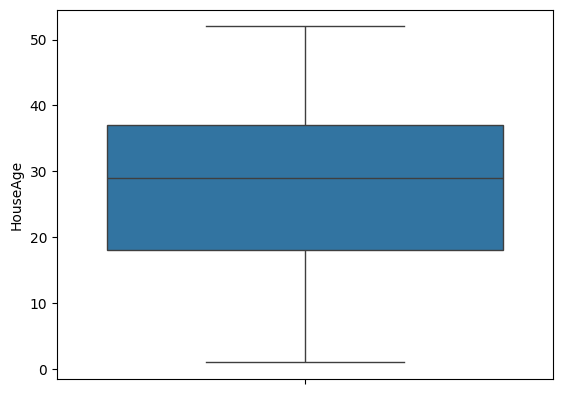

In [20]:
sns.boxplot(df['HouseAge'])
plt.show()

The houseage data doesn't contain any outlier.

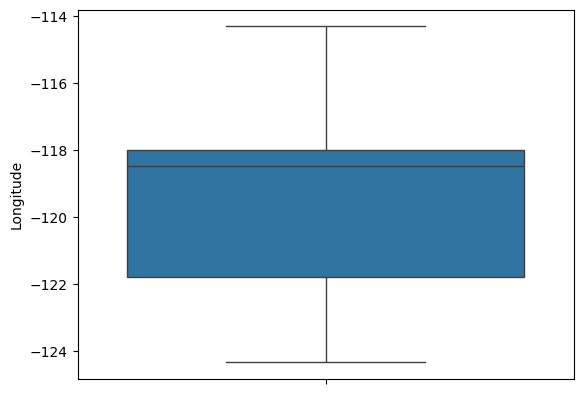

In [21]:
sns.boxplot(df['Longitude'])
plt.show()

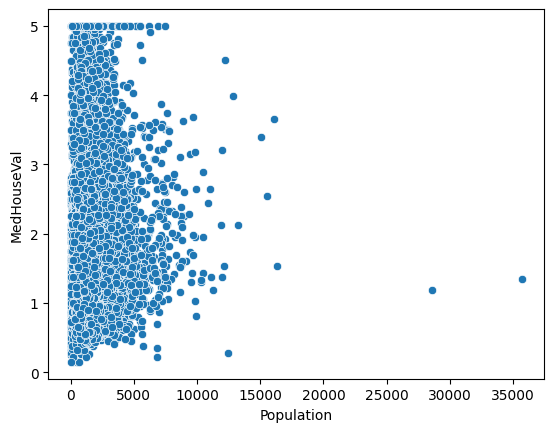

In [22]:
sns.scatterplot(y='MedHouseVal', x='Population', data=df)
plt.show()

## Feature *engineering*

### new feature 1: Rooms per bedrooms

THis feature will indicate how much rooms are there for each bedroom -> It will indicate an estimation of the size of the household.

In [23]:
# adding feature 'RoomsperBedroom' for no of rooms per bedroom.

df['RoomsperBedroom'] = df['AveRooms']/df['AveBedrms']

In [24]:
df['RoomsperBedroom'].describe()

,RoomsperBedroom
count,20640.000000
mean,4.984262
std,1.171836
min,1.000000
25%,4.169542
50%,4.921728
75%,5.700424
max,10.000000


<Axes: xlabel='RoomsperBedroom', ylabel='Count'>

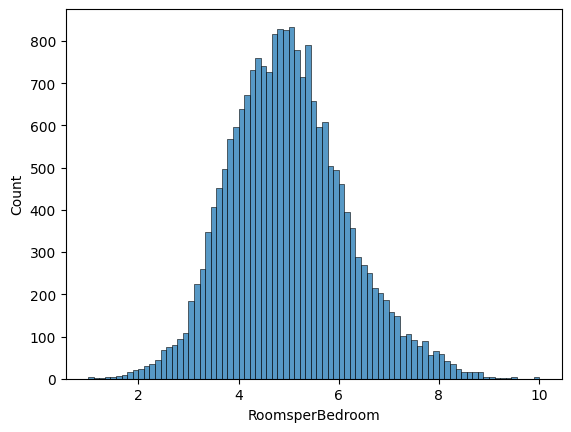

In [25]:
sns.histplot(df['RoomsperBedroom'])

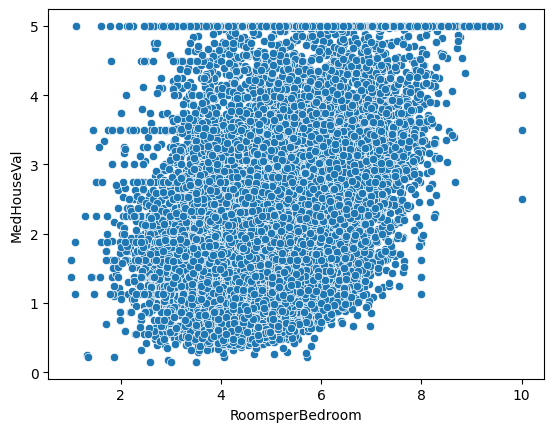

In [26]:
sns.scatterplot(y='MedHouseVal', x='RoomsperBedroom', data=df)
plt.show()

### new feature 2: Population density

This will indicate total no of household.

In [27]:
df['PopulationDensity'] = df['Population']/df['AveOccup']

In [28]:
df['PopulationDensity'].describe()

,PopulationDensity
count,20640.000000
mean,499.539680
std,382.329753
min,1.000000
25%,280.000000
50%,409.000000
75%,605.000000
max,6082.000000


<Axes: xlabel='PopulationDensity', ylabel='Count'>

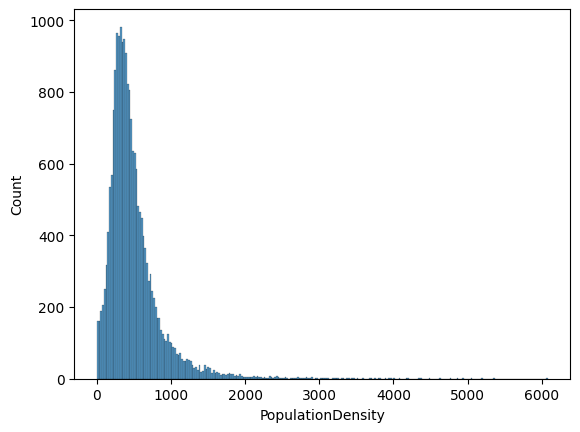

In [29]:
sns.histplot(df['PopulationDensity'])

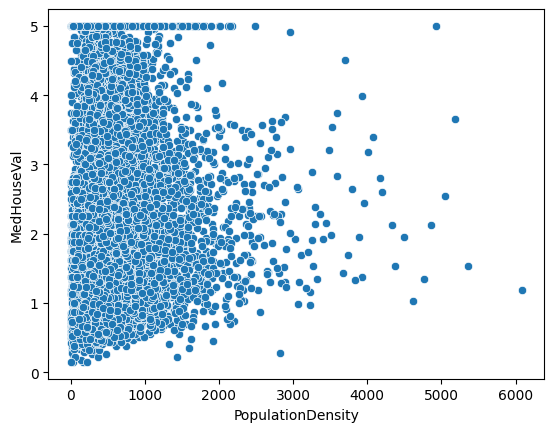

In [30]:
sns.scatterplot(y='MedHouseVal', x='PopulationDensity', data=df)
plt.show()

In [31]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsperBedroom,PopulationDensity
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075,0.766423,0.013033
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623,-0.161295,-0.302916
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948,0.446942,-0.080598
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701,-0.066838,-0.054833
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650,-0.033192,0.907222
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737,-0.001554,-0.027309
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160,0.085180,-0.071035
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967,-0.079533,0.055310
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000,0.383672,0.065843
RoomsperBedroom,0.766423,-0.161295,0.446942,-0.066838,-0.033192,-0.001554,0.085180,-0.079533,0.383672,1.000000,-0.068978


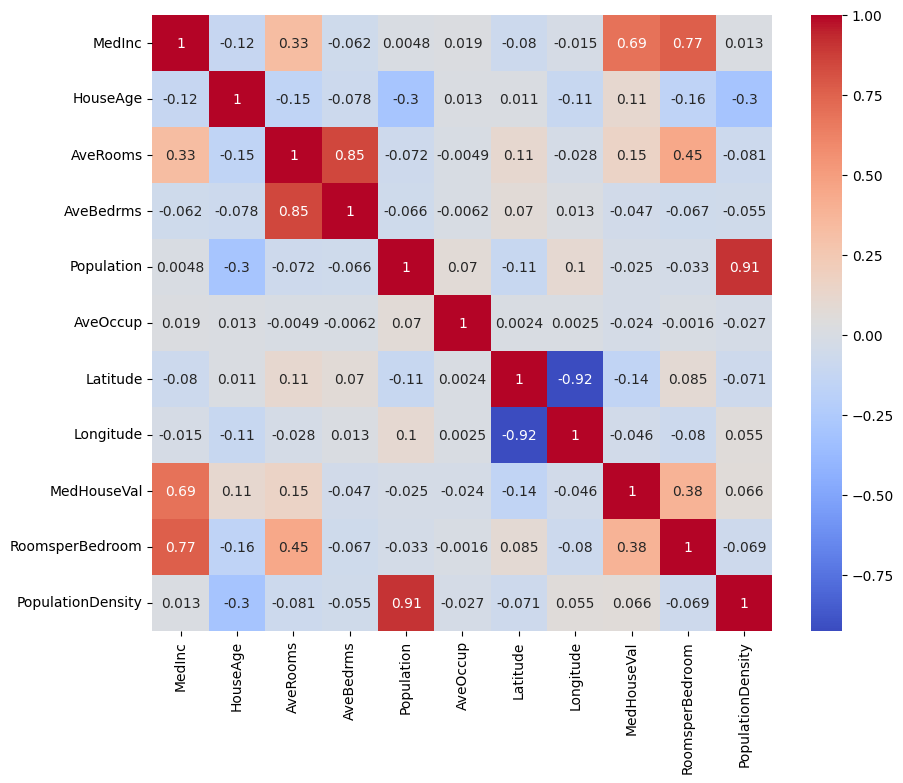

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

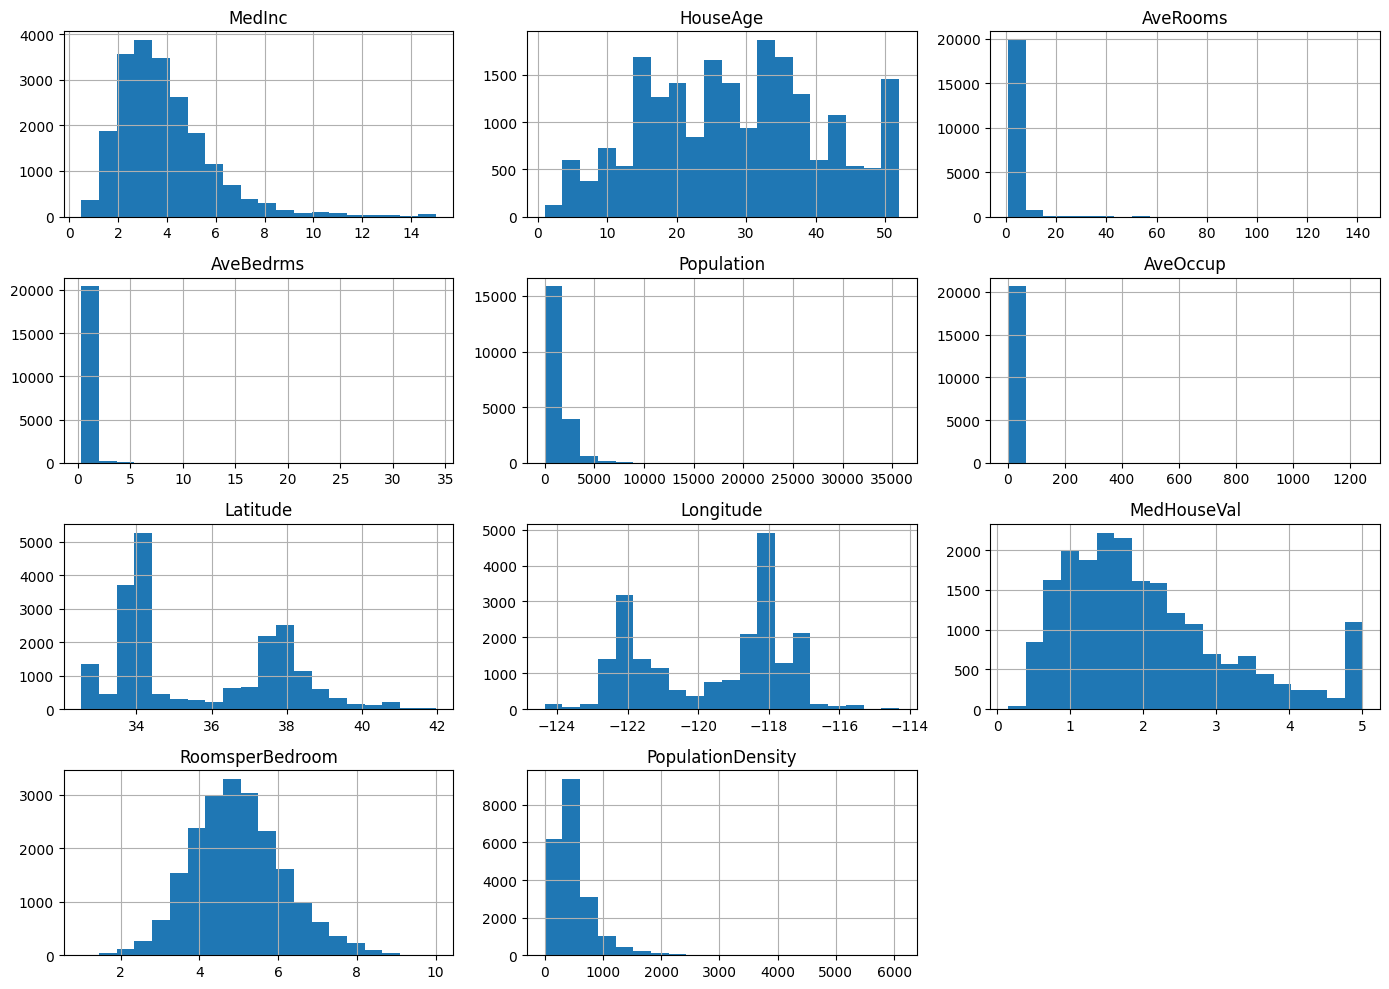

In [33]:
df.hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()

In [34]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsperBedroom,PopulationDensity
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,6.821705,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,6.418626,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,7.721053,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,5.421277,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,5.810714,259.0


## Data Cleaning

### missing values


In [35]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0
RoomsperBedroom,0


As we can see, the dataset doesn't have any missing values.
 So, no action needed

### duplicate values

In [36]:
df.duplicated().sum()


np.int64(0)

As we can see, the dataset doesn't have any duplicated values. So,no action needed.

-- data splitting before outliers handling to prevent data leakage

In [37]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## outliers

### Medinc

<Axes: xlabel='MedInc', ylabel='Density'>

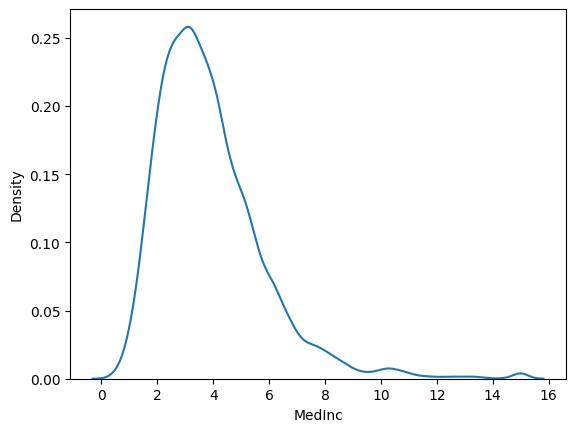

In [38]:
sns.kdeplot(X_train['MedInc'])

In [39]:
X_train['MedInc'].skew()

np.float64(1.634089581665841)

MedInc is highly right skewed data, so we will use log transformation in the pipeline

### Houseage

<Axes: xlabel='HouseAge', ylabel='Density'>

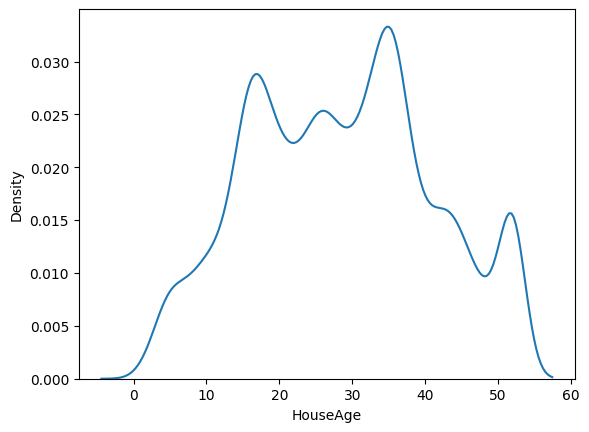

In [ ]:
sns.kdeplot(X_train['HouseAge'])

In [ ]:
X_train['HouseAge'].skew()

np.float64(0.0634534487308965)

Its skewness is very less, so we can use Z-score for outlier detection and handling

practically there are no outliers

### Averooms

<Axes: xlabel='AveRooms', ylabel='Density'>

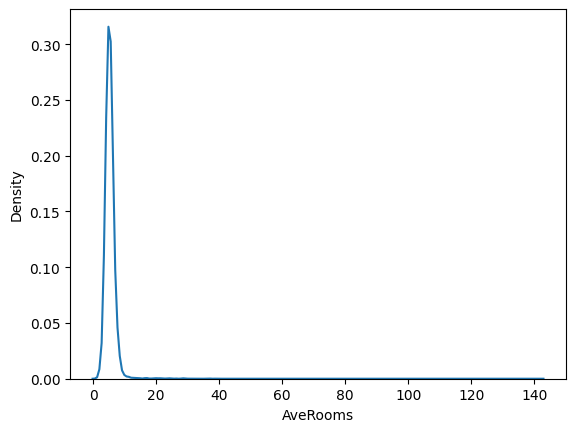

In [ ]:
# sns.kdeplot(X_train['AveRooms'])

this data is highly right skewed. The extreme values doesn't represent outliers, they may be representative of hostels or big hotels where there are lots of rooms.

### average bedrooms

<Axes: xlabel='AveBedrms', ylabel='Density'>

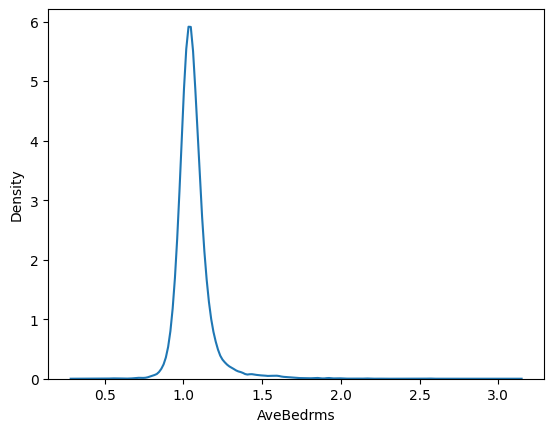

In [ ]:
# sns.kdeplot(X_train['AveBedrms'])

Similar info as averooms.

### Population

<Axes: xlabel='Population', ylabel='Density'>

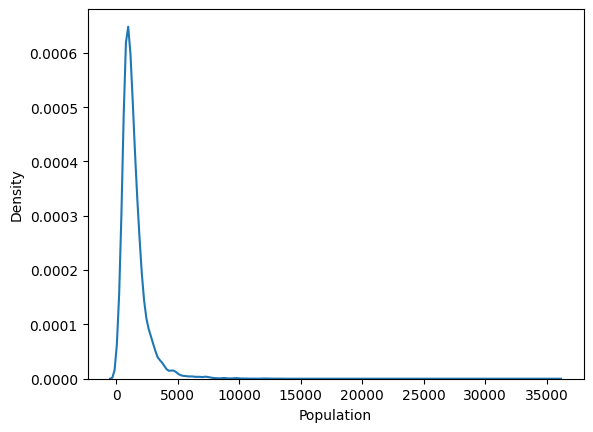

In [ ]:
# sns.kdeplot(X_train['Population'])

Population can have extreme values, so let's not consider those outliers.

### Roomsperbedroom

<Axes: xlabel='RoomsperBedroom', ylabel='Density'>

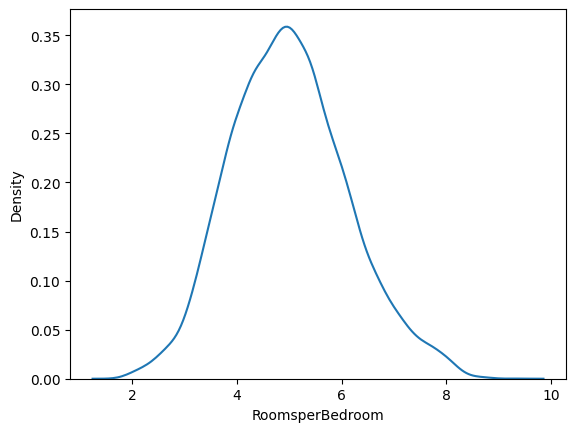

In [ ]:
# sns.kdeplot(X_train['RoomsperBedroom'])

In [ ]:
# X_train['RoomsperBedroom'].skew()

np.float64(0.26960836859892573)

it's beautifully bell curve. Not much outliers.

### PopulationDensity

<Axes: xlabel='PopulationDensity', ylabel='Count'>

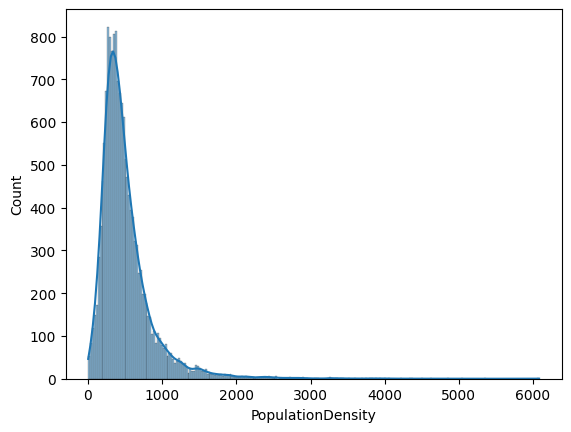

In [ ]:
# sns.histplot(X_train['PopulationDensity'], kde=True)

## baseline model

- without preprocessing and pipelines

In [ ]:
X_train.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'RoomsperBedroom', 'PopulationDensity'],
      dtype='object')

In [40]:
import time

In [41]:
LR_start = time.time()

base_model = LinearRegression()
base_model.fit(X_train, y_train)

LR_end = time.time()

LR_time = LR_end - LR_start

In [42]:
LR_time

0.028338909149169922

In [43]:
base_pred = base_model.predict(X_test)

In [105]:
base_coef = base_model.coef_
base_intercept = base_model.intercept_

print(f"Base model coefficient: {base_coef}")
print('Base model intercept: ', base_intercept)

Base model coefficient: [ 4.49581371e-01  1.14856790e-02  7.40611968e-02 -1.75357784e-01
 -4.01474821e-04  3.78115630e-04 -4.04859916e-01 -4.08760227e-01
 -2.10992085e-01  1.31097735e-03]
Base model intercept:  -33.69282848577067


In [44]:
# evaluation

base_mae = mean_absolute_error(y_test, base_pred)
base_mse = mean_squared_error(y_test, base_pred)
base_rmse = np.sqrt(base_mse)
base_r2 = r2_score(y_test, base_pred)

print(f"Base model MAE: {base_mae}")
print(f"Base model MSE: {base_mse}")
print(f"Base model RMSE: {base_rmse}")
print(f"Base model R2: {base_r2}")

Base model MAE: 0.5077709376611416
Base model MSE: 0.48822999046997934
Base model RMSE: 0.6987345636720567
Base model R2: 0.6274216686721865


In [97]:
cross_val_LR = cross_val_score(
    base_model,
    X_train, y_train,
    cv=5,
    scoring='r2')

cross_val_LR.mean()

np.float64(0.6444733498016182)

## Ridge

In [51]:
Ridge_start = time.time()

base_ridge = Ridge(alpha = 0.0001, max_iter = 100000)
base_ridge.fit(X_train, y_train)

Ridge_end = time.time()
Ridge_time = Ridge_end - Ridge_start

In [52]:
base_ridge

Ridge(alpha=0.0001, max_iter=100000)

In [46]:
Ridge_time

0.013164281845092773

In [47]:
ridge_pred = base_ridge.predict(X_test)

In [104]:
ridge_coef = base_ridge.coef_
ridge_intercept = base_ridge.intercept_

print(f"Base Ridge model coefficient: {ridge_coef}")
print('Base Ridge model intercept: ', ridge_intercept)

Base Ridge model coefficient: [ 4.49581369e-01  1.14856792e-02  7.40611462e-02 -1.75357536e-01
 -4.01474821e-04  3.78115659e-04 -4.04859910e-01 -4.08760220e-01
 -2.10992026e-01  1.31097736e-03]
Base Ridge model intercept:  -33.692828168331985


In [48]:
## evaluation

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Base Ridge model MAE: {ridge_mae}")
print(f"Base Ridge model MSE: {ridge_mse}")
print(f"Base Ridge model RMSE: {ridge_rmse}")
print(f"Base Ridge model R2: {ridge_r2}")

Base Ridge model MAE: 0.5077709381896245
Base Ridge model MSE: 0.4882299936004946
Base Ridge model RMSE: 0.6987345659121886
Base Ridge model R2: 0.6274216662832262


In [98]:
cross_val_ridge = cross_val_score(
    base_ridge,
    X_train, y_train,
    cv=5,
    scoring='r2')

cross_val_ridge.mean()

np.float64(0.6444733505631602)

## Lasso

In [70]:
Lasso_start = time.time()

base_lasso = Lasso(alpha = 0.0001, max_iter = 100000)
base_lasso.fit(X_train, y_train)

Lasso_end = time.time()

Lasso_time = Lasso_end - Lasso_start

In [71]:
base_lasso

Lasso(alpha=0.0001, max_iter=100000)

In [72]:
Lasso_time

0.10853981971740723

In [73]:
lasso_pred = base_lasso.predict(X_test)

In [103]:
lasso_coef = base_lasso.coef_
lasso_intercept = base_lasso.intercept_

print(f"Base Lasso model coefficient: {lasso_coef}")
print('Base Lasso model intercept: ', lasso_intercept)

Base Lasso model coefficient: [ 4.49377948e-01  1.14955460e-02  6.90290917e-02 -1.50594029e-01
 -4.01479232e-04  3.80362559e-04 -4.04731188e-01 -4.08591224e-01
 -2.05220173e-01  1.31135921e-03]
Base Lasso model intercept:  -33.70549686529513


In [74]:
# evaluation

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"Base Lasso model MAE: {lasso_mae}")
print(f"Base Lasso model MSE: {lasso_mse}")
print(f"Base Lasso model RMSE: {lasso_rmse}")
print(f"Base Lasso model R2 : {lasso_r2}")

Base Lasso model MAE: 0.5078290808741284
Base Lasso model MSE: 0.48855752950983034
Base Lasso model RMSE: 0.6989689045371262
Base Lasso model R2 : 0.6271717169049981


In [99]:
cross_val_lasso = cross_val_score(
    base_lasso,
    X_train, y_train,
    cv=5,
    scoring='r2')

cross_val_lasso.mean()

np.float64(0.6444927703844286)

## Random Forest

In [75]:
# time


rf_start = time.time()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_end = time.time()

In [78]:
rf_time = rf_end - rf_start
rf_time

35.30932903289795

In [77]:
## evaluation


rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Base Random Forest model MAE: {rf_mae}")
print(f"Base Random Forest model MSE: {rf_mse}")
print(f"Base Random Forest model RMSE: {rf_rmse}")
print(f"Base Random Forest model R2: {rf_r2}")

Base Random Forest model MAE: 0.32883211637596915
Base Random Forest model MSE: 0.2552540887669524
Base Random Forest model RMSE: 0.5052267696460199
Base Random Forest model R2: 0.8052103633251911


Final Evaluation: Random Forest outperformed the linear models because it can capture nonlinear relationships and interactions between features that Linear Regression and Ridge cannot model effectively. The improvement in both RMSE and R² suggests that the housing dataset contains complex patterns beyond a simple linear relationship.

### feature importance

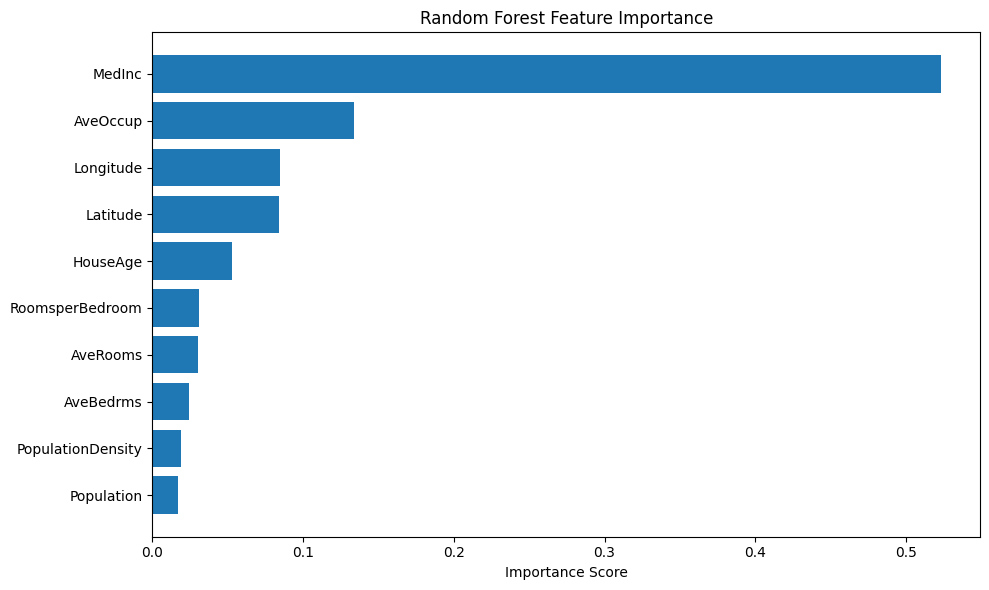

In [79]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("/content/figures/feature_importance.png", dpi=300)
plt.show()

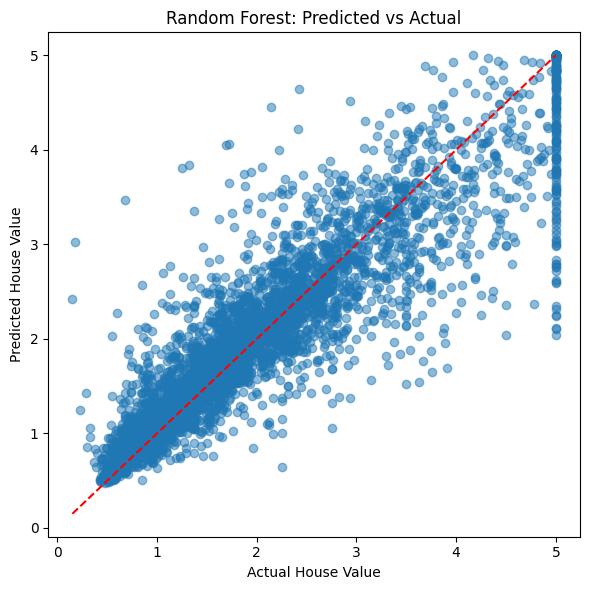

In [80]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Random Forest: Predicted vs Actual")
plt.tight_layout()
plt.savefig("figures/predicted_vs_actual.png", dpi=300)
plt.show()

## Extra Trees Regressor

In [81]:
et_start = time.time()

et = ExtraTreesRegressor(
    random_state=42
)

et.fit(X_train, y_train)

et_end = time.time()

et_pred = et.predict(X_test)

In [82]:
et_time = et_end - et_start
et_time

15.11094069480896

In [83]:
# eVALUATION

et_mae = mean_absolute_error(y_test, et_pred)
et_mse = mean_squared_error(y_test, et_pred)
et_rmse = np.sqrt(et_mse)
et_r2 = r2_score(y_test, et_pred)

print(f"Base Extra Trees model MAE: {et_mae}")
print(f"Base Extra Trees model MSE: {et_mse}")
print(f"Base Extra Trees model RMSE: {et_rmse}")
print(f"Base Extra Trees model R2: {et_r2}")

Base Extra Trees model MAE: 0.342399325145349
Base Extra Trees model MSE: 0.26844021129139634
Base Extra Trees model RMSE: 0.5181121609182672
Base Extra Trees model R2: 0.7951477624552359


## Comparison of the models

In [102]:
# comparison of all models

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Extra Trees'],
    'MAE': [base_mae, ridge_mae, lasso_mae, rf_mae, et_mae],
    'MSE': [base_mse, ridge_mse, lasso_mse, rf_mse, et_mse],
    'RMSE': [base_rmse, ridge_rmse, lasso_rmse, rf_rmse, et_rmse],
    'R2': [base_r2, ridge_r2, lasso_r2, rf_r2, et_r2],
    'Training Time' : [LR_time, Ridge_time, Lasso_time, rf_time, et_time]
})

comparison

,Model,MAE,MSE,RMSE,R2,Training Time
0,Linear Regression,0.507771,0.488230,0.698735,0.627422,0.028339
1,Ridge,0.507771,0.488230,0.698735,0.627422,0.007594
2,Lasso,0.507829,0.488558,0.698969,0.627172,0.108540
3,Random Forest,0.328832,0.255254,0.505227,0.805210,35.309329
4,Extra Trees,0.342399,0.268440,0.518112,0.795148,15.110941


In [94]:
comparison.to_csv('/content/results/result.csv', index=False)

## figures

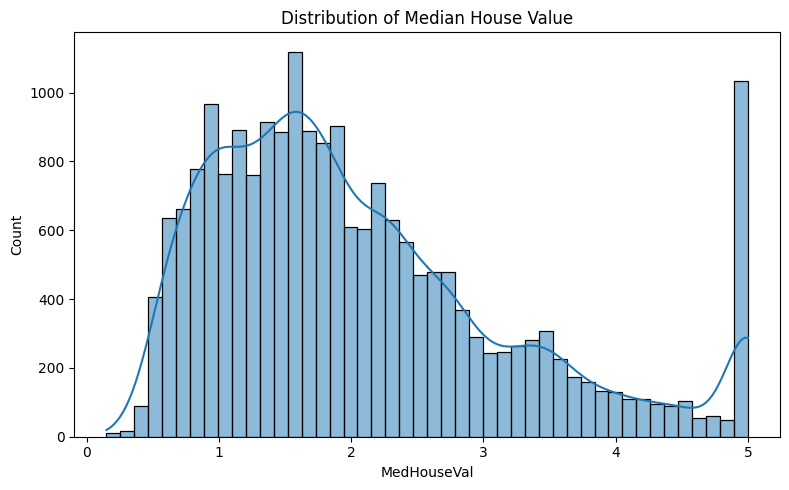

In [89]:
plt.figure(figsize=(8,5))
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribution of Median House Value")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=300)

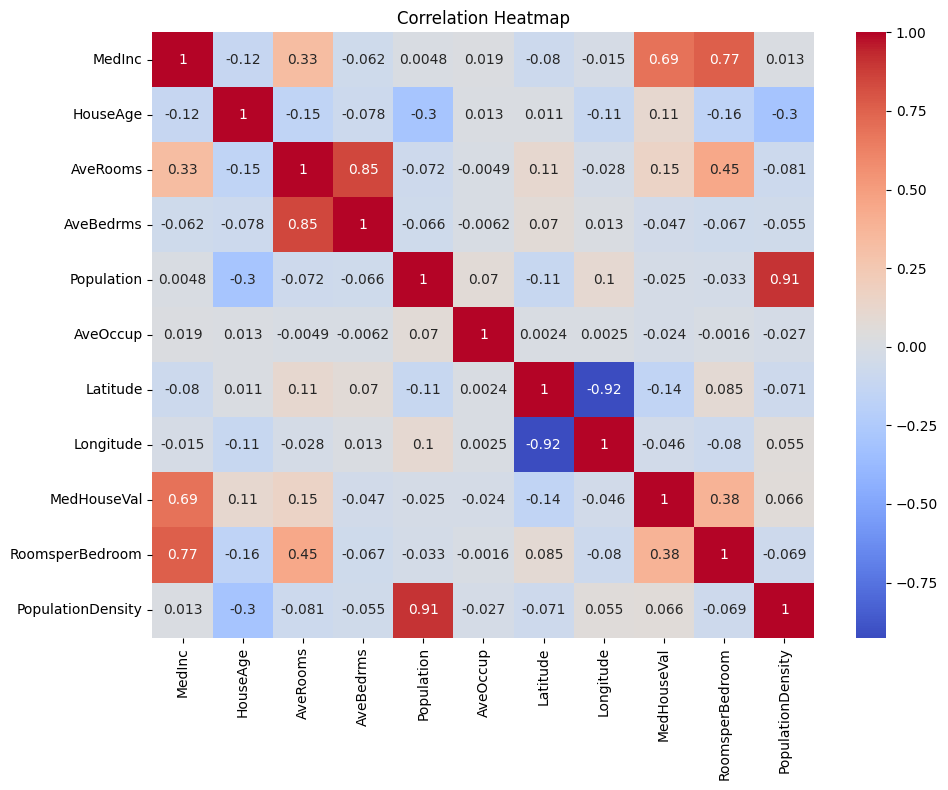

In [90]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)

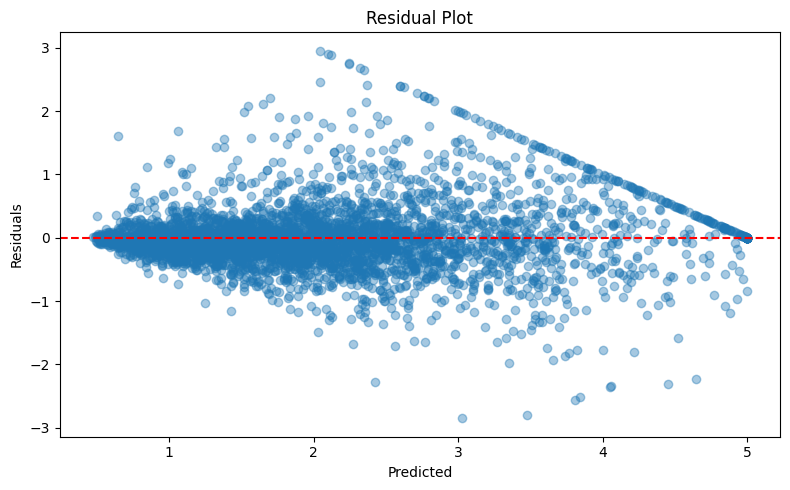

In [91]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))
plt.scatter(rf_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("figures/residual_plot.png", dpi=300)

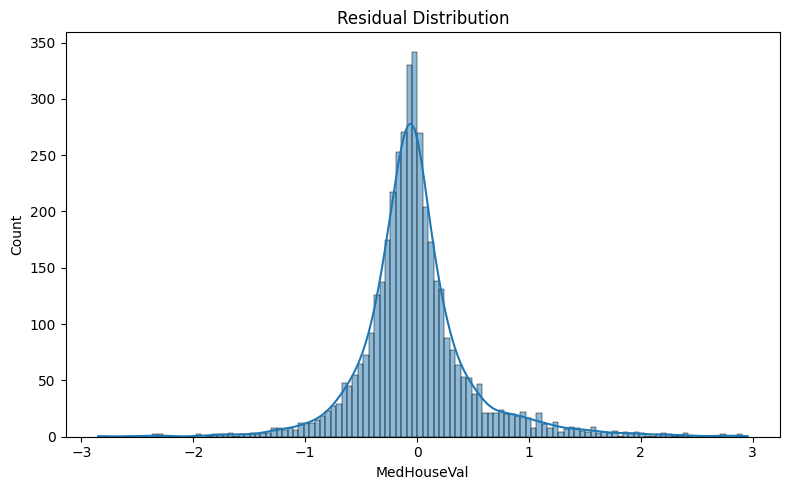

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig("figures/residual_distribution.png", dpi=300)